Number of input files: 1000


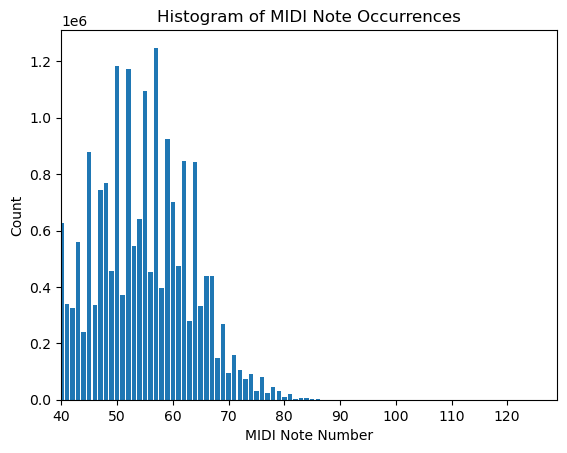

Number of silence frames (no notes on): 0


In [4]:
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'

input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)
input_filepaths=input_filepaths[:1000]
feature_description = {
    "input":  tf.io.FixedLenFeature([], tf.string),
    "output": tf.io.FixedLenFeature([], tf.string),
}


print(f'Number of input files: {len(input_filepaths)}')

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = tf.io.decode_raw(parsed["input"], tf.float32)
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio, label

def create_dataset(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

def count_midi_notes(dataset):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    for audio, label in dataset:
        output_data = label.numpy()  # Reshape to (num_frames, 89)
        # print(output_data.shape)
        for note in range(OUTPUT_DIM_NOTES):
            if output_data[note] == 1:
                hist[note] += 1
            
    return hist

def plot_histogram(hist):
    plt.bar(range(OUTPUT_DIM_NOTES), hist)
    plt.xlabel('MIDI Note Number')
    plt.ylabel('Count')
    plt.title('Histogram of MIDI Note Occurrences')
    plt.xlim(40, OUTPUT_DIM_NOTES)  # Limit x-axis to the range of interest
    plt.show()

dataset = create_dataset(input_filepaths)
midi_histogram = count_midi_notes(dataset)
plot_histogram(midi_histogram)
# print no of silence frames
print("Number of silence frames (no notes on):", midi_histogram[OUTPUT_DIM_NOTES-1])
# def midi_hist(input_filepaths):
#     hist =[]# np.zeros((89,), dtype=int)
#     for output_filepath in input_filepaths:
#         ds=tf.data.TFRecordDataset(output_filepath)
#         parsed = tf.io.parse_single_example(ds, feature_description)
#         audio = tf.io.decode_raw(parsed["input"], tf.float32)
#         label = tf.io.decode_raw(parsed["output"], tf.int8)
    
#         output_data = label.numpy().reshape(-1, 89)  # Reshape to (num_frames, 89)
#         for frame in output_data:
#             for note in range(89):
#                 if frame[note] == 1:
#                     hist.append(note)
#     plt.hist(hist,range(40,89))
  

# midi_hist(input_filepaths)





In [6]:
#EDIT: THIS PART HAS MOVED TO TRAINING.IPYNB!

# # The limit of samples with midi notes off to be put into the trainingset
# sailent_thresh=20000 
# current_sailent_count=np.zeros(89,dtype=int)
# selected_outfiles=[]
# selected_infiles=[]
 
# rng=np.random.default_rng(123)
# perm=rng.permutation(len(output_filepaths))
# output_filepaths=[output_filepaths[i] for i in perm]
# input_filepaths=[input_filepaths[i] for i in perm]
# # for i,output_filepath in enumerate(output_filepaths):
# #     output_data=np.load(output_filepath)


#     # # print(output_data.shape)
#     # # print("out path:", output_filepath)
#     # # print("in path:", input_filepaths[i])
#     # if output_data[0][88]>0:
#     #     if current_sailent_count[88]<sailent_thresh:
#     #         selected_outfiles.append(output_filepath)
#     #         selected_infiles.append(input_filepaths[i])
#     #         current_sailent_count[88]+=1
#     # else:
#     #     selected_outfiles.append(output_filepath)
#     #     selected_infiles.append(input_filepaths[i])


# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)
#     copydata=True
#     for note in range(89):
#         if output_data[0][note]>0:
#             if current_sailent_count[note]>sailent_thresh:
#                 copydata=False

#     # print(output_data.shape)
#     # print("out path:", output_filepath)
#     # print("in path:", input_filepaths[i])

#     if copydata:
#         selected_outfiles.append(output_filepath)
#         selected_infiles.append(input_filepaths[i])
#         for note in range(89):
#             if output_data[0][note]>0:
#                 current_sailent_count[note]+=1
   


In [7]:
# import shutil



# # os.makedirs(trin,exist_ok=True)
# print("Selected files count:",len(selected_outfiles))
# for i,output_filepath in enumerate(selected_outfiles):
   
#     output_filename=os.path.basename(output_filepath)
#     input_filename=os.path.basename(selected_infiles[i])
#     parentdir=os.path.dirname(os.path.dirname(output_filepath))
#     destin_dir=os.path.join(subset,os.path.basename(parentdir))
#     os.makedirs(destin_dir,exist_ok=True)
#     trin=os.path.join(destin_dir,'input')
#     trout=os.path.join(destin_dir,'output')
#     os.makedirs(trin,exist_ok=True)
#     os.makedirs(trout,exist_ok=True)
#     fout=os.path.join(trout,output_filename)
#     fin=os.path.join(trin,input_filename)
#     # print('Copying ',output_filepath,' to ',fout)
#     shutil.copyfile(output_filepath,fout)
    
#     # print('Copying ',selected_infiles[i],' to ',fin)
#     shutil.copyfile(selected_infiles[i],fin)
    

# print("Final midi hist:")
# output_filepaths = sorted(glob.glob(os.path.join(subset, '**', 'output', '*.npy'), recursive=True))
# midi_hist(output_filepaths)


